[*********************100%***********************]  1 of 1 completed


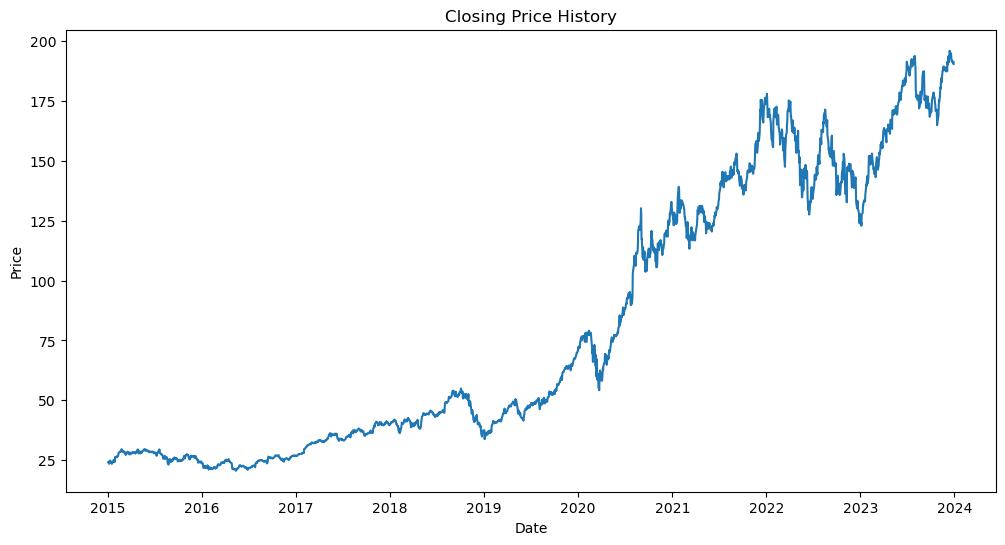

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - loss: 0.0050 - val_loss: 0.0010
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 7.3798e-04 - val_loss: 9.3378e-04
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 7.6245e-04 - val_loss: 0.0096
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 71ms/step - loss: 7.0363e-04 - val_loss: 7.7787e-04
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - loss: 5.3578e-04 - val_loss: 0.0012
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 5.8022e-04 - val_loss: 9.9812e-04
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 77ms/step - loss: 4.9222e-04 - val_loss: 7.7321e-04
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 72ms/step - loss: 5.1327e-04 - val_loss: 7.2158e-04
Epoch 9/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - loss: 4.9688e-04 - val_loss: 0.0010
Epoch 10/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - loss: 4.0768e-04 - val_loss: 8.2502e-04
Epoch 11/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 72ms/step - loss: 4.2064e-04 - val_loss: 9.406

In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input


data = yf.download("AAPL", start="2015-01-01", end="2024-01-01")


data.columns = data.columns.droplevel(1)
data.reset_index(inplace=True)
data.set_index('Date', inplace=True)


data = data[['Close']]
data.columns.name = None


plt.figure(figsize=(12,6))
plt.plot(data)
plt.title('Closing Price History')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()


scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)


X = []
y = []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i])

X, y = np.array(X), np.array(y)


split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


model = Sequential([
    Input(shape=(60,1)),
    
    LSTM(50, return_sequences=True),
    Dropout(0.25),
    
    LSTM(50),
    Dropout(0.25),
    
    Dense(1)
])



model.compile(optimizer='adam', loss='mean_squared_error')

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model.fit(
    X_train, y_train,
    epochs=50,
    validation_split=0.2,
    callbacks=[early_stop]
)



14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step
MSE: 32.387898352150636
RMSE: 5.691036667616071


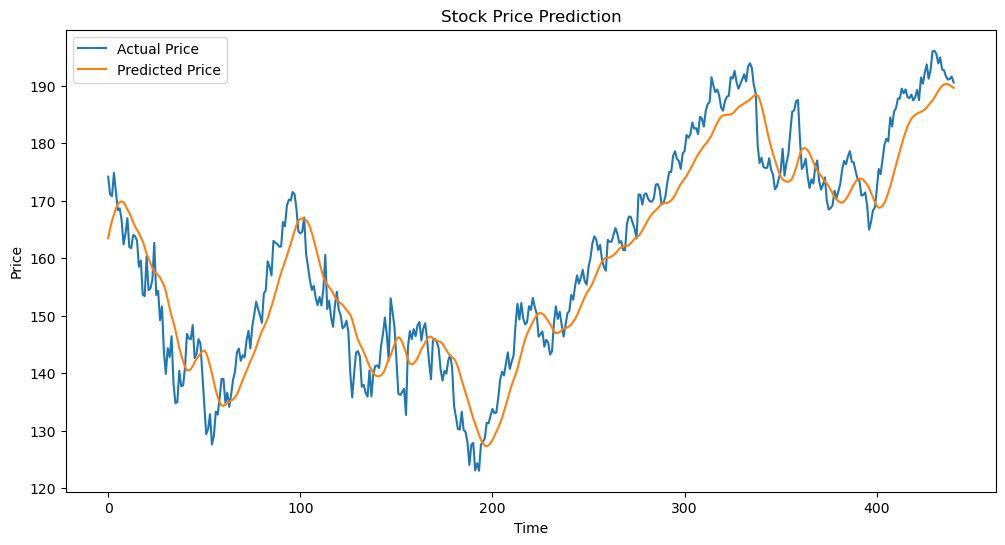

In [16]:

prediction = model.predict(X_test)


predicted = scaler.inverse_transform(prediction)
y_test_actual = scaler.inverse_transform(y_test)


mse = mean_squared_error(y_test_actual, predicted)
rmse = np.sqrt(mse)

print("MSE:", mse)
print("RMSE:", rmse)


plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predicted, label="Predicted Price")
plt.title("Stock Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.show()